In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

pd.set_option('display.max_rows', 8) # 设置数据框显示最大行数



数据源：本笔记使用的GDP和常驻人口数据来自[国家统计局分省市年度数据](https://data.stats.gov.cn/easyquery.htm)

## 读取数据

In [2]:
df1 = pd.read_excel('../data/分省年度-地区生产总值(亿元).xlsx')
df1.iloc[np.r_[0:4,-2:0], 0:5]

,数据库：分省年度数据,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,指标：地区生产总值(亿元),NaN,NaN,NaN,NaN
1,时间：1992-2023,NaN,NaN,NaN,NaN
2,地区,2022年,2021年,2020年,2019年
3,北京市,41610.9,41045.6,35943.3,35445.1
33,新疆维吾尔自治区,17741.3,16311.6,13800.7,13597.1
34,数据来源：国家统计局,NaN,NaN,NaN,NaN


<br>
从统计局网站下载的数据，附带了非表格的说明，需要跳过表头说明（3行）和表脚注（1行）

> 参加[`pd.read_execl`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_excel.html)
手册说明

In [4]:
df1 = pd.read_excel('../data/分省年度-地区生产总值(亿元).xlsx', skiprows=3, skipfooter=1)  #跳过表头和表尾
df1.iloc[np.r_[0:4,-2:0], 0:5] #筛选部分数据来初步探索 目前数据为宽格式

,地区,2022年,2021年,2020年,2019年
0,北京市,41610.9,41045.6,35943.3,35445.1
1,天津市,16311.3,15685.1,14008.0,14055.5
2,河北省,42370.4,40397.1,36013.8,34978.6
3,山西省,25642.6,22870.4,17835.6,16961.6
29,宁夏回族自治区,5069.6,4588.2,3956.3,3748.5
30,新疆维吾尔自治区,17741.3,16311.6,13800.7,13597.1


<br>
将数据转换成长格式，数据字段包括地区、年度和GDP

In [5]:
df1 = pd.read_excel('../data/分省年度-地区生产总值(亿元).xlsx', skiprows=3, skipfooter=1)

df1.melt(id_vars='地区')  #首先要设置不变的地区,再修改变量名为'年度'，value_name='GDP'

,地区,variable,value
0,北京市,2022年,41610.9
1,天津市,2022年,16311.3
2,河北省,2022年,42370.4
3,山西省,2022年,25642.6
...,...,...,...
957,甘肃省,1992年,317.8
958,青海省,1992年,87.5
959,宁夏回族自治区,1992年,83.1
960,新疆维吾尔自治区,1992年,402.3


In [6]:
df1 = pd.read_excel('../data/分省年度-地区生产总值(亿元).xlsx', skiprows=3, skipfooter=1)

df1 = df1.melt(id_vars='地区', var_name='年度', value_name='GDP') #首先要设置不变的地区
df1.年度 = df1.年度.str.replace('年', '').astype(int)
df1

,地区,年度,GDP
0,北京市,2022,41610.9
1,天津市,2022,16311.3
2,河北省,2022,42370.4
3,山西省,2022,25642.6
...,...,...,...
957,甘肃省,1992,317.8
958,青海省,1992,87.5
959,宁夏回族自治区,1992,83.1
960,新疆维吾尔自治区,1992,402.3


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 961 entries, 0 to 960
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   地区      961 non-null    object 
 1   年度      961 non-null    int32  
 2   GDP     961 non-null    float64
dtypes: float64(1), int32(1), object(1)
memory usage: 18.9+ KB


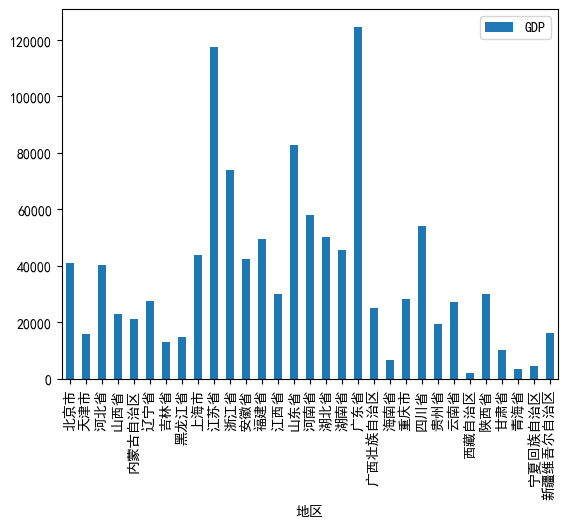

In [8]:
df1[df1.年度==2021].plot.bar(x='地区', y='GDP');  #但是这种图意义不大，比较有难度，需要先排序

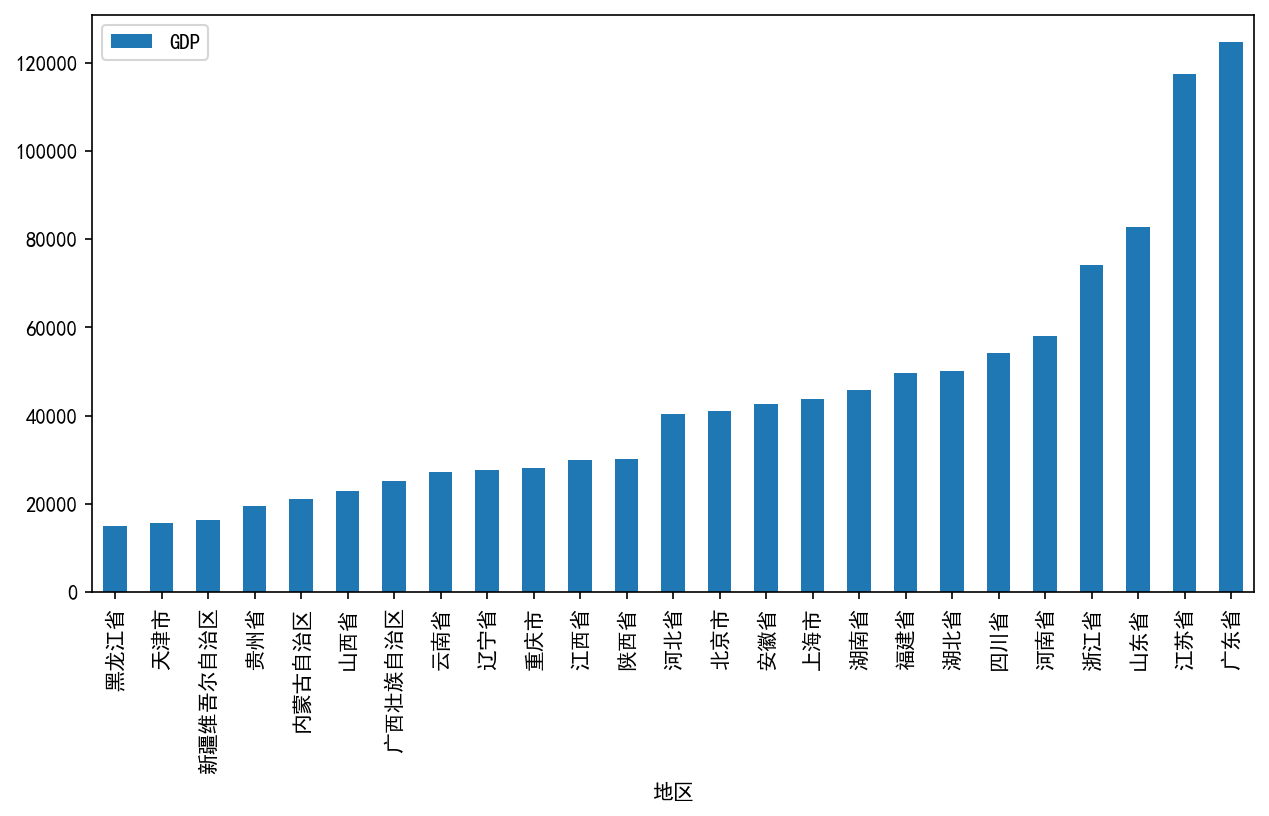

In [9]:
#ax= df1[df1.年度==2021].sort_values(by="GDP")[-25:].plot(kind='bar',x='地区', y='GDP');   #2021年度GDP前25名 柱状图
fig,ax = plt.subplots(1,1,figsize=(10, 5), dpi=150)  #当子图subpolts为1行1列时，其实就为一个图，返回的参数ax就只有1个
df1[df1.年度==2021].sort_values(by="GDP")[-25:].plot(kind='bar',x='地区', y='GDP',ax=ax);

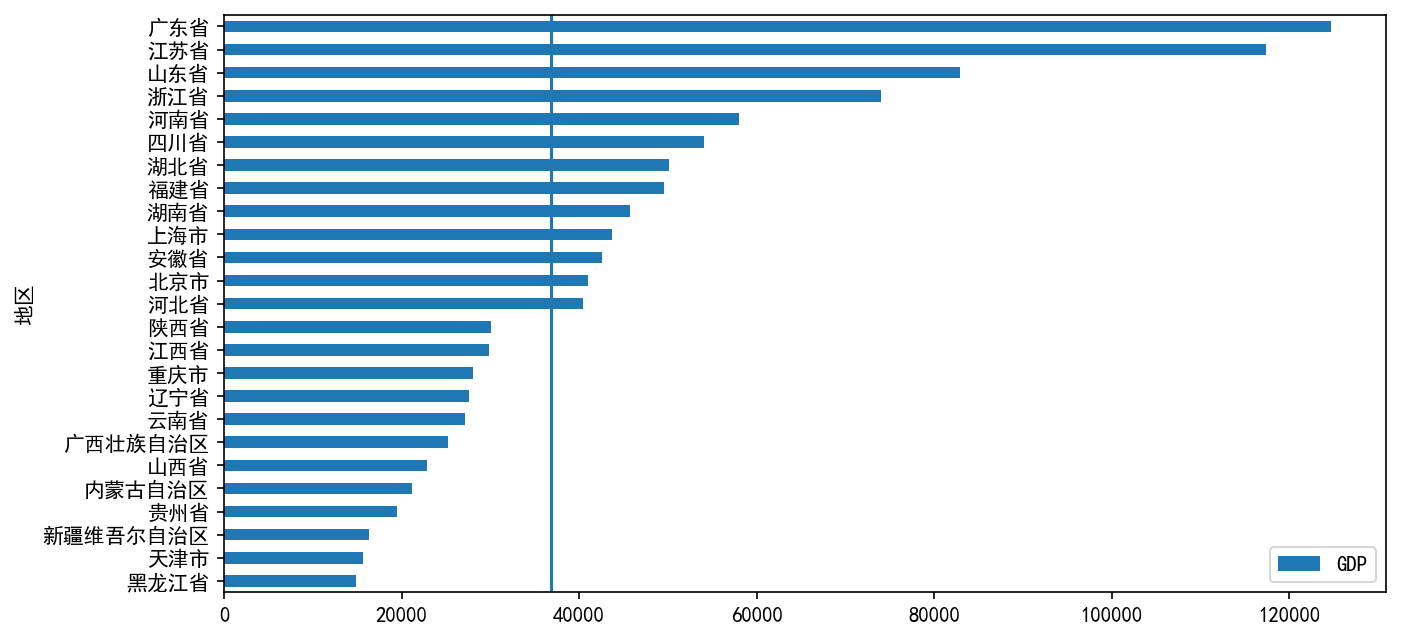

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
df1[df1.年度==2021].sort_values(by="GDP")[-25:].plot.barh(x='地区', y='GDP', ax=ax) #画条形图时是从0点开始画，所以先画的最小值，最上面的是最大值
a=df1[df1.年度==2021].GDP.mean()
ax.axvline(a)    #把2021年度GDP值的均值作为衡量标准线 

In [11]:
df1[df1.年度==2021].GDP

31    41045.6
32    15685.1
33    40397.1
34    22870.4
       ...   
58    10225.5
59     3385.1
60     4588.2
61    16311.6
Name: GDP, Length: 31, dtype: float64

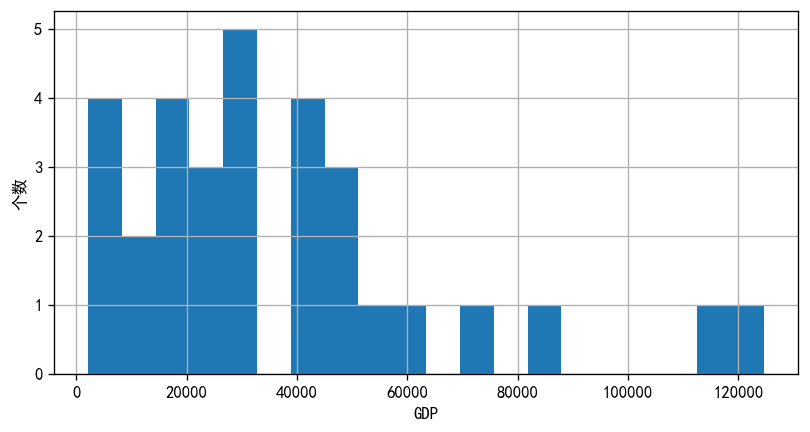

In [169]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
df1[df1.年度==2021].GDP.plot.hist(bins=20, ax=ax)
ax.set_xlabel('GDP'); ax.set_ylabel('个数'); ax.grid()  #设置x，y轴标签；ax.grid() 是一个用于在图表的轴对象上绘制网格的方法。这个方法可以增强图表的可读性，使得观察者能够更容易地估计数据点的位置。

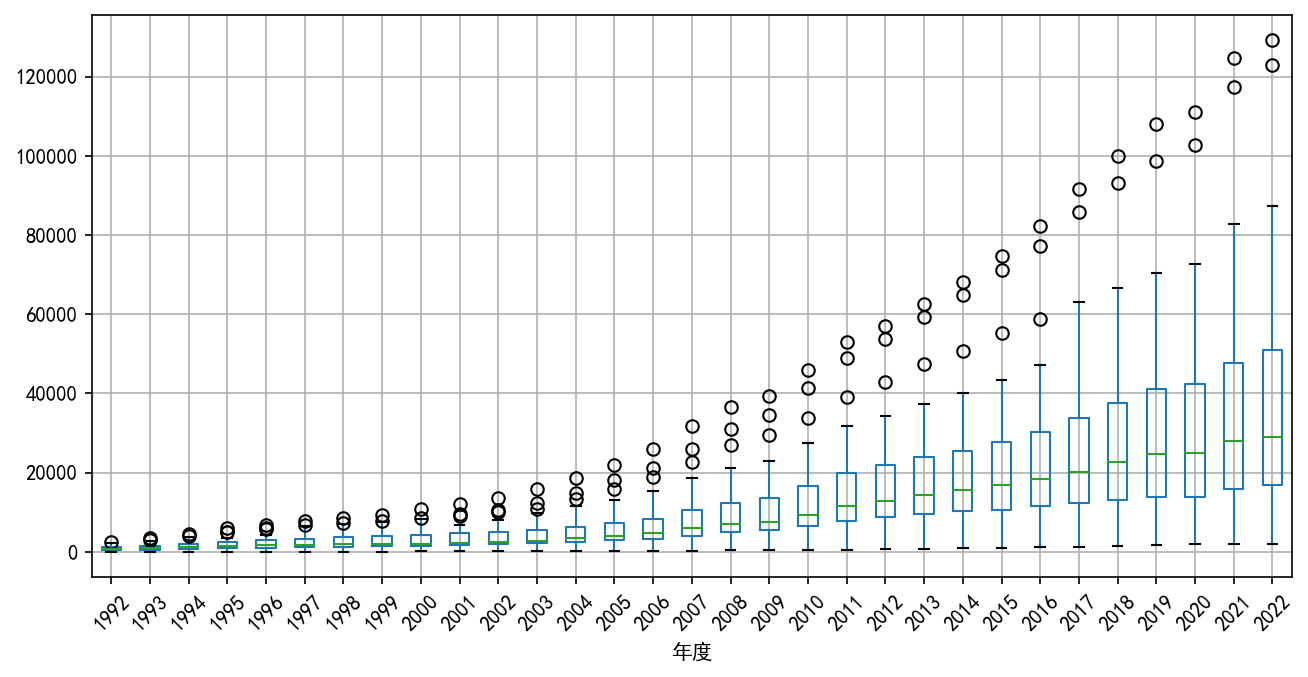

In [170]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
df1.boxplot(column='GDP', by='年度', rot=45,ax=ax)
#ax.tick_params(axis='x', rotation=45)  #设置x轴 倾斜45度
ax.set_title(''); fig.suptitle('');

### 直辖市GDP增长趋势

In [171]:
df1

,地区,年度,GDP
0,北京市,2022,41610.9
1,天津市,2022,16311.3
2,河北省,2022,42370.4
3,山西省,2022,25642.6
...,...,...,...
957,甘肃省,1992,317.8
958,青海省,1992,87.5
959,宁夏回族自治区,1992,83.1
960,新疆维吾尔自治区,1992,402.3


In [172]:
dft = df1.pivot(index="年度", columns="地区")
dft

GDP                                                                \
地区        上海市      云南省   内蒙古自治区      北京市      吉林省      四川省      天津市 宁夏回族自治区   
年度                                                                            
1992   1114.3    618.7    421.7    710.2    558.1   1177.3    411.0    83.1   
1993   1519.2    783.3    537.8    888.9    718.6   1486.1    538.9   104.5   
1994   1990.9    983.8    695.1   1149.8    937.7   2001.4    732.9   136.3   
1995   2518.1   1222.2    857.1   1516.2   1137.2   2443.2    932.0   175.2   
...       ...      ...      ...      ...      ...      ...      ...     ...   
2019  37987.6  23223.8  17212.5  35445.1  11726.8  46363.8  14055.5  3748.5   
2020  38963.3  24555.7  17258.0  35943.3  12256.0  48501.6  14008.0  3956.3   
2021  43653.2  27161.6  21166.0  41045.6  13163.8  54088.0  15685.1  4588.2   
2022  44652.8  28954.2  23158.6  41610.9  13070.2  56749.8  16311.3  5069.6   

                        ...                                              \
地区        安徽省      山东省  ...      湖南省      甘肃省      福建省   西藏自治区      贵州省   
年度                      ...                                               
1992    827.0   2196.5  ...    987.0    317.8    784.7    33.3    339.9   
1993   1073.5   2770.4  ...   1244.7    372.2   1114.2    37.4    417.7   
1994   1378.9   3844.5  ...   1650.0    453.6   1644.4    46.0    524.5   
1995   1891.2   4953.4  ...   2132.1    557.8   2094.9    56.1    636.2   
...       ...      ...  ...      ...      ...      ...     ...      ...   
2019  36845.5  70540.5  ...  39894.1   8718.3  42326.6  1697.8  16769.3   
2020  38061.5  72798.2  ...  41542.6   8979.7  43608.6  1902.7  17860.4   
2021  42565.2  82875.2  ...  45713.5  10225.5  49566.1  2080.2  19458.6   
2022  45045.0  87435.1  ...  48670.4  11201.6  53109.9  2132.6  20164.6   

                                                  
地区        辽宁省      重庆市      陕西省     青海省     黑龙江省  
年度                                                
1992   1473.0    462.5    531.6    87.5    857.4  
1993   2010.8    611.1    678.2   109.7   1075.3  
1994   2461.8    838.1    839.0   138.4   1448.1  
1995   2793.4   1130.6   1036.9   167.8   1790.2  
...       ...      ...      ...     ...      ...  
2019  24855.3  23605.8  25793.2  2941.1  13544.4  
2020  25011.4  25041.4  26014.1  3009.8  13633.4  
2021  27569.5  28077.3  30121.7  3385.1  14858.2  
2022  28975.1  29129.0  32772.7  3610.1  15901.0  

[31 rows x 31 columns]

In [173]:
dft = df1.pivot(index="年度", columns="地区")
dft = dft.GDP[['北京市', '上海市', '重庆市', '天津市']]
dft.tail(5)

地区,北京市,上海市,重庆市,天津市
年度,,,,
2018,33106.0,36011.8,21588.8,13362.9
2019,35445.1,37987.6,23605.8,14055.5
2020,35943.3,38963.3,25041.4,14008.0
2021,41045.6,43653.2,28077.3,15685.1
2022,41610.9,44652.8,29129.0,16311.3


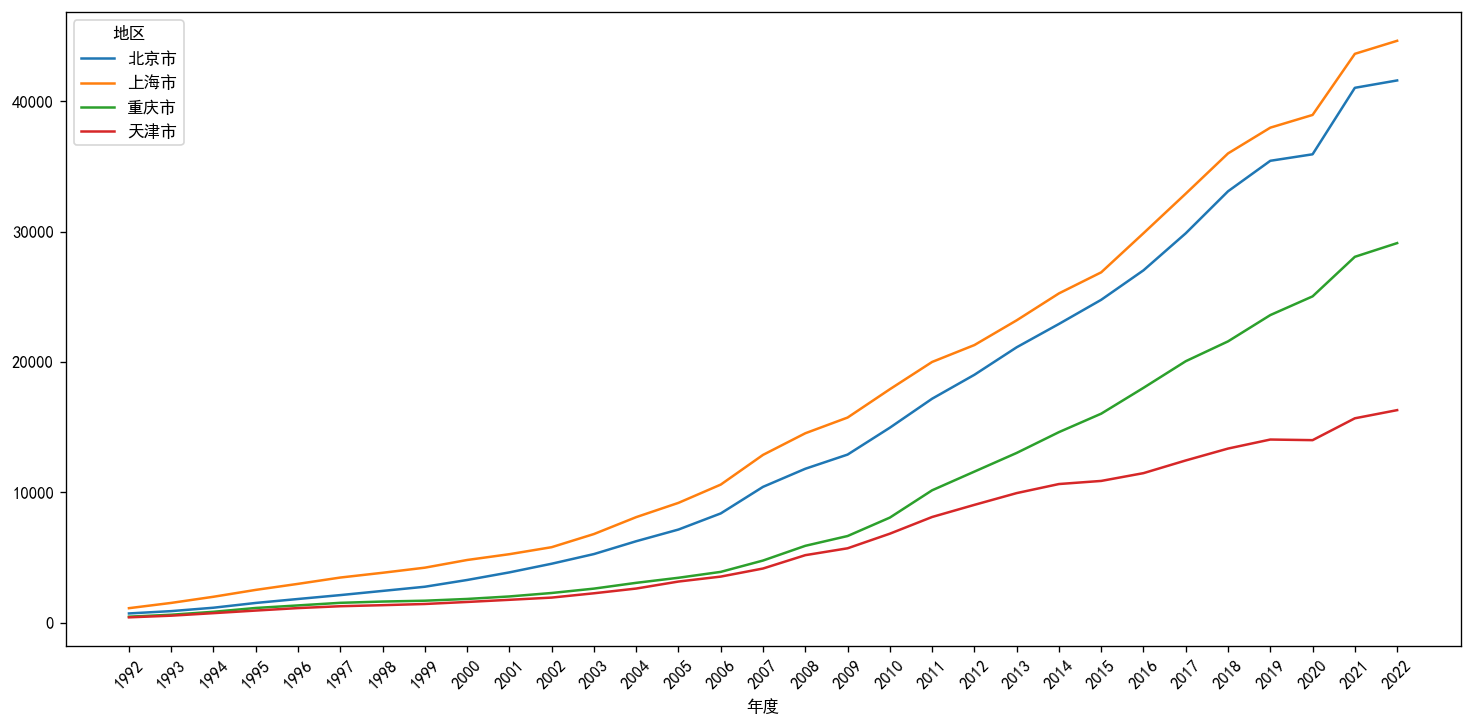

In [174]:
fig, ax = plt.subplots(figsize=(15, 7), dpi=120)
dft.plot.line(ax=ax)
ax.set_xticks(dft.index)
ax.tick_params(axis='x', rotation=45)

<br>
计算增长率   


In [175]:
dft.shift(periods=1) #shift 方法用于将数据沿着某个轴移动。periods=1：将每行（或每列，取决于轴的设置）的数据向下移动一个位置。periods=-1：将每行（或每列）的数据向上移动一个位置。

地区,北京市,上海市,重庆市,天津市
年度,,,,
1992,NaN,NaN,NaN,NaN
1993,710.2,1114.3,462.5,411.0
1994,888.9,1519.2,611.1,538.9
1995,1149.8,1990.9,838.1,732.9
...,...,...,...,...
2019,33106.0,36011.8,21588.8,13362.9
2020,35445.1,37987.6,23605.8,14055.5
2021,35943.3,38963.3,25041.4,14008.0
2022,41045.6,43653.2,28077.3,15685.1


In [84]:
dft / dft.shift(periods=1) - 1   #当期值/前期值-1  

地区,北京市,上海市,重庆市,天津市
年度,,,,
1992,NaN,NaN,NaN,NaN
1993,0.251619,0.363367,0.321297,0.311192
1994,0.293509,0.310492,0.371461,0.359993
1995,0.318664,0.264805,0.349004,0.271661
...,...,...,...,...
2019,0.070655,0.054865,0.093428,0.051830
2020,0.014056,0.025685,0.060816,-0.003379
2021,0.141954,0.120367,0.121235,0.119724
2022,0.013772,0.022899,0.037457,0.039923


In [85]:
dft.pct_change(periods=1) #也可以对DataFrame或Series使用 pct_change() ，它会返回一个新的序列，其中每个元素是原始序列中该位置元素与其前一个元素的百分比变化。

地区,北京市,上海市,重庆市,天津市
年度,,,,
1992,NaN,NaN,NaN,NaN
1993,0.251619,0.363367,0.321297,0.311192
1994,0.293509,0.310492,0.371461,0.359993
1995,0.318664,0.264805,0.349004,0.271661
...,...,...,...,...
2019,0.070655,0.054865,0.093428,0.051830
2020,0.014056,0.025685,0.060816,-0.003379
2021,0.141954,0.120367,0.121235,0.119724
2022,0.013772,0.022899,0.037457,0.039923


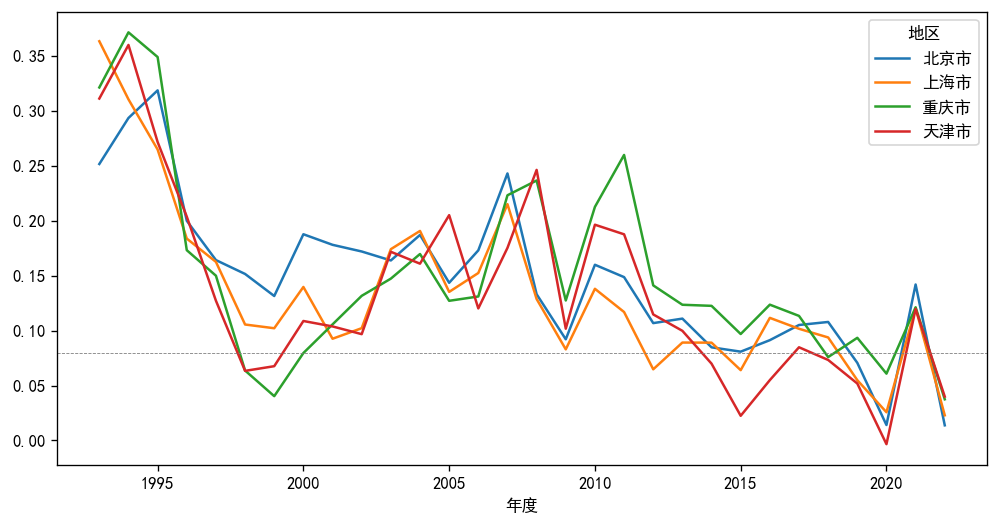

In [86]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
dft.pct_change(periods=1).plot.line(ax=ax)
ax.axhline(0.08, c="grey", lw=0.5, ls="--"); #加的辅助线的配置细节： 0.5灰色虚线

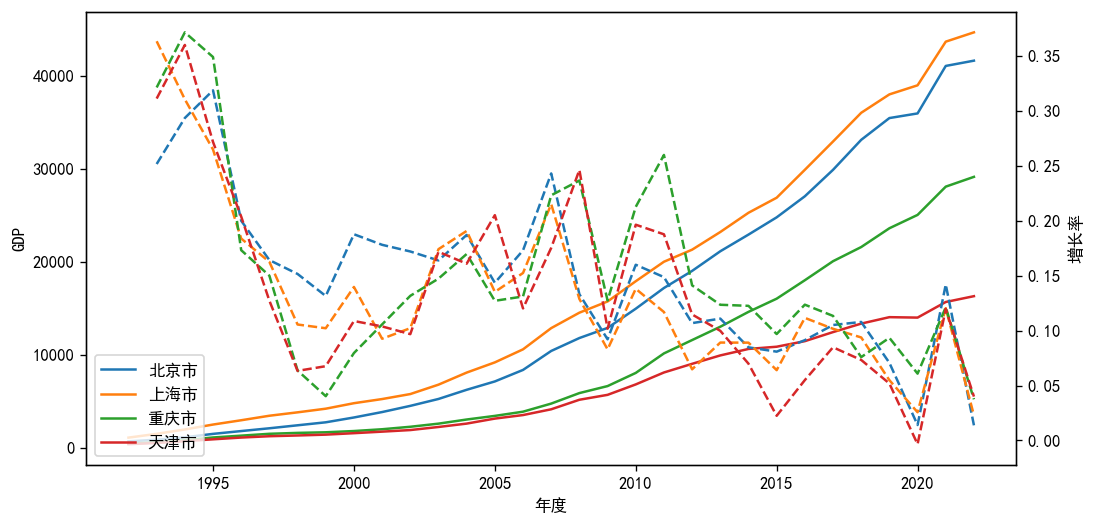

In [87]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
dft.plot.line(ax=ax)


ax2 = ax.twinx() # 获得附属坐标系
dft.pct_change(periods=1).plot.line(ax=ax2, ls='--')

ax2.get_legend().remove()
ax.set_ylabel('GDP'); ax2.set_ylabel('增长率');
ax.legend(loc='lower left');

### 按经济区分析

In [107]:
df1

,地区,年度,GDP
0,北京市,2022,41610.9
1,天津市,2022,16311.3
2,河北省,2022,42370.4
3,山西省,2022,25642.6
...,...,...,...
957,甘肃省,1992,317.8
958,青海省,1992,87.5
959,宁夏回族自治区,1992,83.1
960,新疆维吾尔自治区,1992,402.3


In [149]:
#网上可以查到相关定义
areas = {
    "长江三角洲": ["上海市", "江苏省", "浙江省"],
    "环渤海地区": ["北京市", "天津市", "河北省", "辽宁省", "山东省"],
    "泛珠三角": ["福建省", "江西省", "湖南省", "广东省", "广西壮族自治区", "海南省", "四川省", "贵州省", "云南省"],
}
df6 = df1.copy()

In [150]:
[(a,cs) for a,cs in areas.items()] #列表推导式，用于遍历字典 areas 中的键值对，并将每个键值对转换成一个元组 (a, cs)，然后收集这些元组到一个列表中。

[('长江三角洲', ['上海市', '江苏省', '浙江省']),
 ('环渤海地区', ['北京市', '天津市', '河北省', '辽宁省', '山东省']),
 ('泛珠三角', ['福建省', '江西省', '湖南省', '广东省', '广西壮族自治区', '海南省', '四川省', '贵州省', '云南省'])]

In [151]:
[(a,c) for a,cs in areas.items() for c in cs]

[('长江三角洲', '上海市'),
 ('长江三角洲', '江苏省'),
 ('长江三角洲', '浙江省'),
 ('环渤海地区', '北京市'),
 ('环渤海地区', '天津市'),
 ('环渤海地区', '河北省'),
 ('环渤海地区', '辽宁省'),
 ('环渤海地区', '山东省'),
 ('泛珠三角', '福建省'),
 ('泛珠三角', '江西省'),
 ('泛珠三角', '湖南省'),
 ('泛珠三角', '广东省'),
 ('泛珠三角', '广西壮族自治区'),
 ('泛珠三角', '海南省'),
 ('泛珠三角', '四川省'),
 ('泛珠三角', '贵州省'),
 ('泛珠三角', '云南省')]

In [152]:
{c:a for a,cs in areas.items() for c in cs}

{'上海市': '长江三角洲',
 '江苏省': '长江三角洲',
 '浙江省': '长江三角洲',
 '北京市': '环渤海地区',
 '天津市': '环渤海地区',
 '河北省': '环渤海地区',
 '辽宁省': '环渤海地区',
 '山东省': '环渤海地区',
 '福建省': '泛珠三角',
 '江西省': '泛珠三角',
 '湖南省': '泛珠三角',
 '广东省': '泛珠三角',
 '广西壮族自治区': '泛珠三角',
 '海南省': '泛珠三角',
 '四川省': '泛珠三角',
 '贵州省': '泛珠三角',
 '云南省': '泛珠三角'}

In [153]:
d={}
for a, cs in areas.items():
    for c in cs:
        d[c] = a
d

{'上海市': '长江三角洲',
 '江苏省': '长江三角洲',
 '浙江省': '长江三角洲',
 '北京市': '环渤海地区',
 '天津市': '环渤海地区',
 '河北省': '环渤海地区',
 '辽宁省': '环渤海地区',
 '山东省': '环渤海地区',
 '福建省': '泛珠三角',
 '江西省': '泛珠三角',
 '湖南省': '泛珠三角',
 '广东省': '泛珠三角',
 '广西壮族自治区': '泛珠三角',
 '海南省': '泛珠三角',
 '四川省': '泛珠三角',
 '贵州省': '泛珠三角',
 '云南省': '泛珠三角'}

In [156]:
df6.地区.map({c: a for a, cs in areas.items() for c in cs})  #map方法用于将列中的每个元素映射到一个新值。

0      环渤海地区
1      环渤海地区
2      环渤海地区
3        NaN
       ...  
957      NaN
958      NaN
959      NaN
960      NaN
Name: 地区, Length: 961, dtype: object

In [157]:
areas = {   
    "长江三角洲": ["上海市", "江苏省", "浙江省"],
    "环渤海地区": ["北京市", "天津市", "河北省", "辽宁省", "山东省"],
    "泛珠三角": ["福建省", "江西省", "湖南省", "广东省", "广西壮族自治区", "海南省", "四川省", "贵州省", "云南省"],
}

df6 = df1.copy()
df6["经济区"] = df6.地区.map({c: a for a, cs in areas.items() for c in cs})
df6

,地区,年度,GDP,经济区
0,北京市,2022,41610.9,环渤海地区
1,天津市,2022,16311.3,环渤海地区
2,河北省,2022,42370.4,环渤海地区
3,山西省,2022,25642.6,NaN
...,...,...,...,...
957,甘肃省,1992,317.8,NaN
958,青海省,1992,87.5,NaN
959,宁夏回族自治区,1992,83.1,NaN
960,新疆维吾尔自治区,1992,402.3,NaN


In [117]:
df7 = df6.groupby(['经济区', '年度'])['GDP'].sum().reset_index()
df7

,经济区,年度,GDP
0,泛珠三角,1992,7759.2
1,泛珠三角,1993,10370.4
2,泛珠三角,1994,13901.6
3,泛珠三角,1995,17499.5
...,...,...,...
89,长江三角洲,2019,199106.4
90,长江三角洲,2020,206460.1
91,长江三角洲,2021,235086.4
92,长江三角洲,2022,245243.8


In [118]:
df7 = df7.pivot(index='年度', columns='经济区')
df7.tail(5)

GDP                    
经济区       泛珠三角     环渤海地区     长江三角洲
年度                                
2018  301353.6  169122.9  187222.2
2019  327799.7  179875.0  199106.4
2020  340689.6  183774.7  206460.1
2021  382248.3  207572.5  235086.4
2022  401961.3  216702.8  245243.8

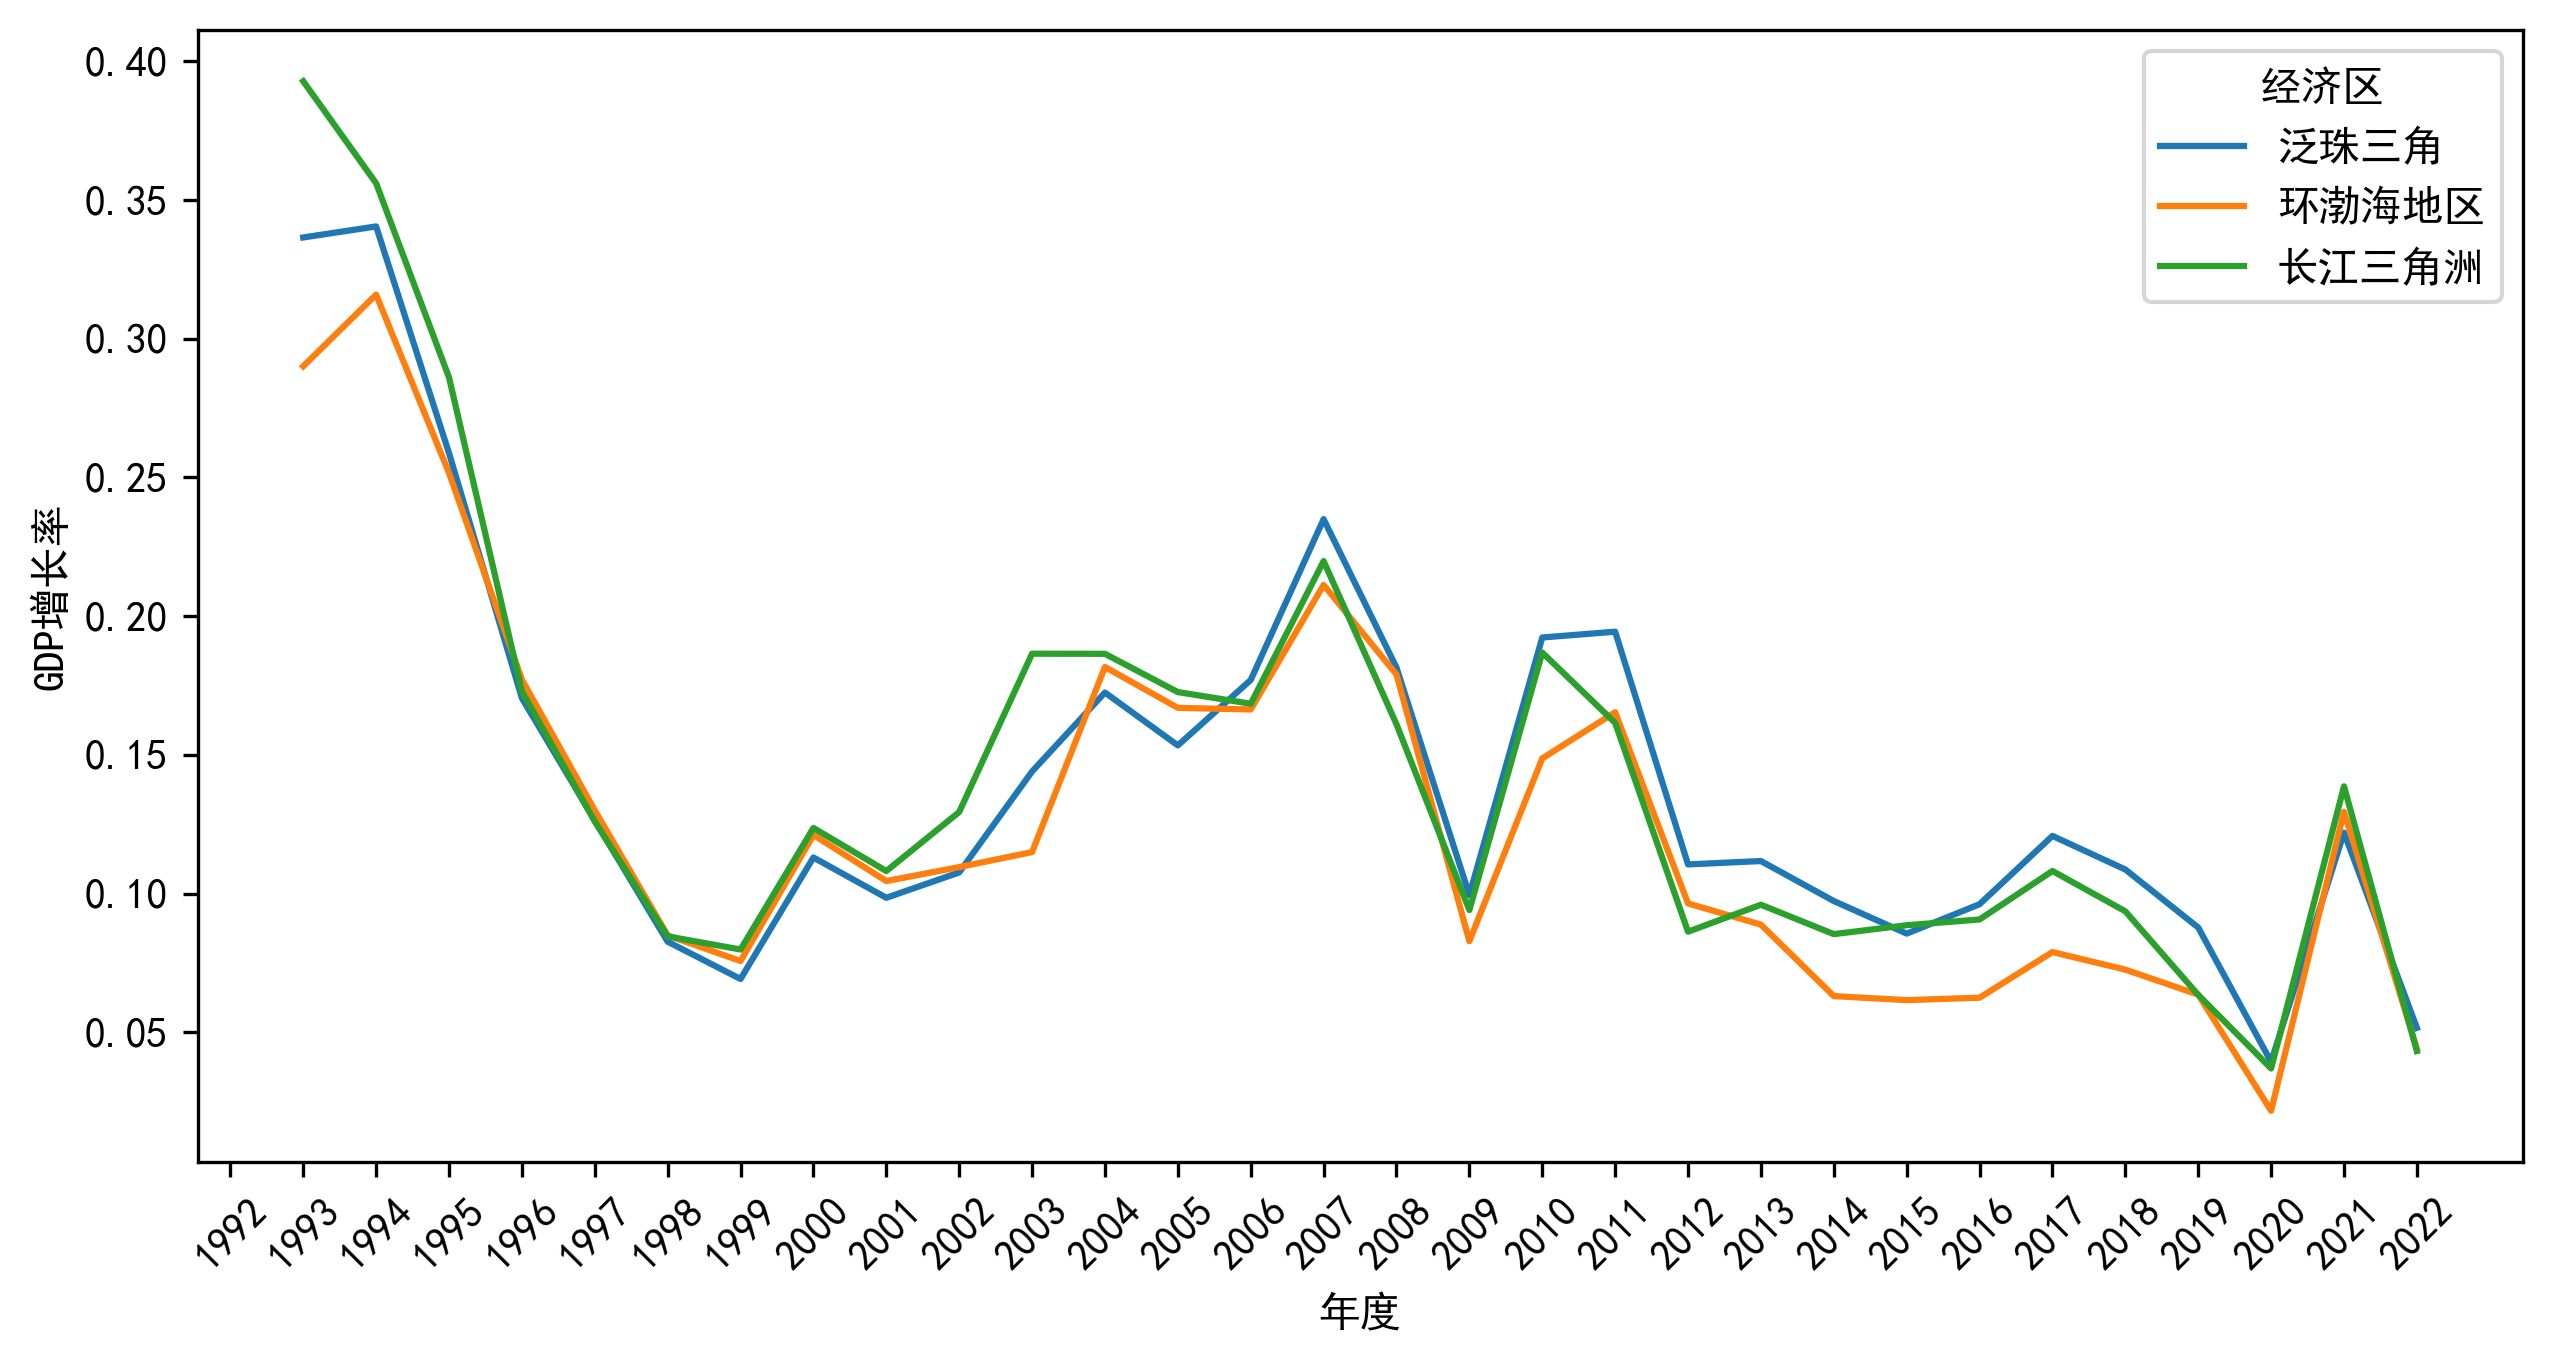

In [158]:
fig, ax= plt.subplots(1, 1, figsize=(10, 5), dpi=300)
df7.GDP.pct_change(periods=1).plot.line(ax=ax,rot=45)
ax.set_xticks(df7.index)
#ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("GDP增长率");